# Лабораторная работа №5

**Тема:** Порядково-статистические фильтры для бинарных и полутоновых изображений

**Студент:** Косило Павел Андреевич

## 1. Теоретическая справка

Порядково-статистический фильтр ранга $k$ в окне $W$ строится следующим образом: значения пикселей, попавшие в окно, упорядочиваются по возрастанию, после чего в качестве нового значения центрального пикселя выбирается элемент с номером $k$.

Для квадратного окна размера $S \times S$ число элементов равно $n = S^2$. Наиболее важные частные случаи:

- **Минимум**: выбирается наименьшее значение в окне. Для бинарных и полутоновых изображений это соответствует эрозии.
- **Медиана**: выбирается средний элемент упорядоченного набора. Такой фильтр хорошо подавляет импульсный шум типа «соль и перец».
- **Максимум**: выбирается наибольшее значение в окне. Для бинарных и полутоновых изображений это соответствует дилатации.

В работе рассматриваются квадратные окна размеров `3x3`, `5x5` и `7x7`. Программа иллюстрирует действие этих фильтров на бинарном и полутоновом изображениях, и сравнивает результат для разных размеров окна.

## 2. Исходные изображения

Для демонстрации работы порядково-статистических фильтров программа формирует два синтетических изображения и добавляет к ним импульсный шум типа «соль и перец»:

1. **Бинарное изображение**: светлый квадрат с тёмным круглым отверстием.
2. **Полутоновое изображение**: плавный рельеф яркости, сформированный синусоидальными и градиентными компонентами.

В визуализации показываются как исходные чистые изображения, так и зашумленные версии, на которых затем применяются фильтры минимума, медианы и максимума для окон `3x3`, `5x5` и `7x7`.

## 3. Код программы

Ниже приведён код, который:

1. Генерирует бинарное и полутоновое изображения.
2. Добавляет на них импульсный шум.
3. Применяет фильтры минимума, медианы и максимума для окон `3x3`, `5x5` и `7x7`.
4. Выводит численные характеристики и визуализирует результаты обработки.

Бинарное изображение
Ошибочных пикселей в зашумленном изображении: 2371
Окно 3x3: минимум = 4368, медиана = 53, максимум = 14118
Окно 5x5: минимум = 8216, медиана = 76, максимум = 26797
Окно 7x7: минимум = 10226, медиана = 83, максимум = 33980

Полутоновое изображение
Средняя абсолютная ошибка в зашумленном изображении: 12.66
Окно 3x3: минимум = 52.34, медиана = 0.48, максимум = 48.43
Окно 5x5: минимум = 98.76, медиана = 0.63, максимум = 90.62
Окно 7x7: минимум = 123.54, медиана = 0.81, максимум = 112.41



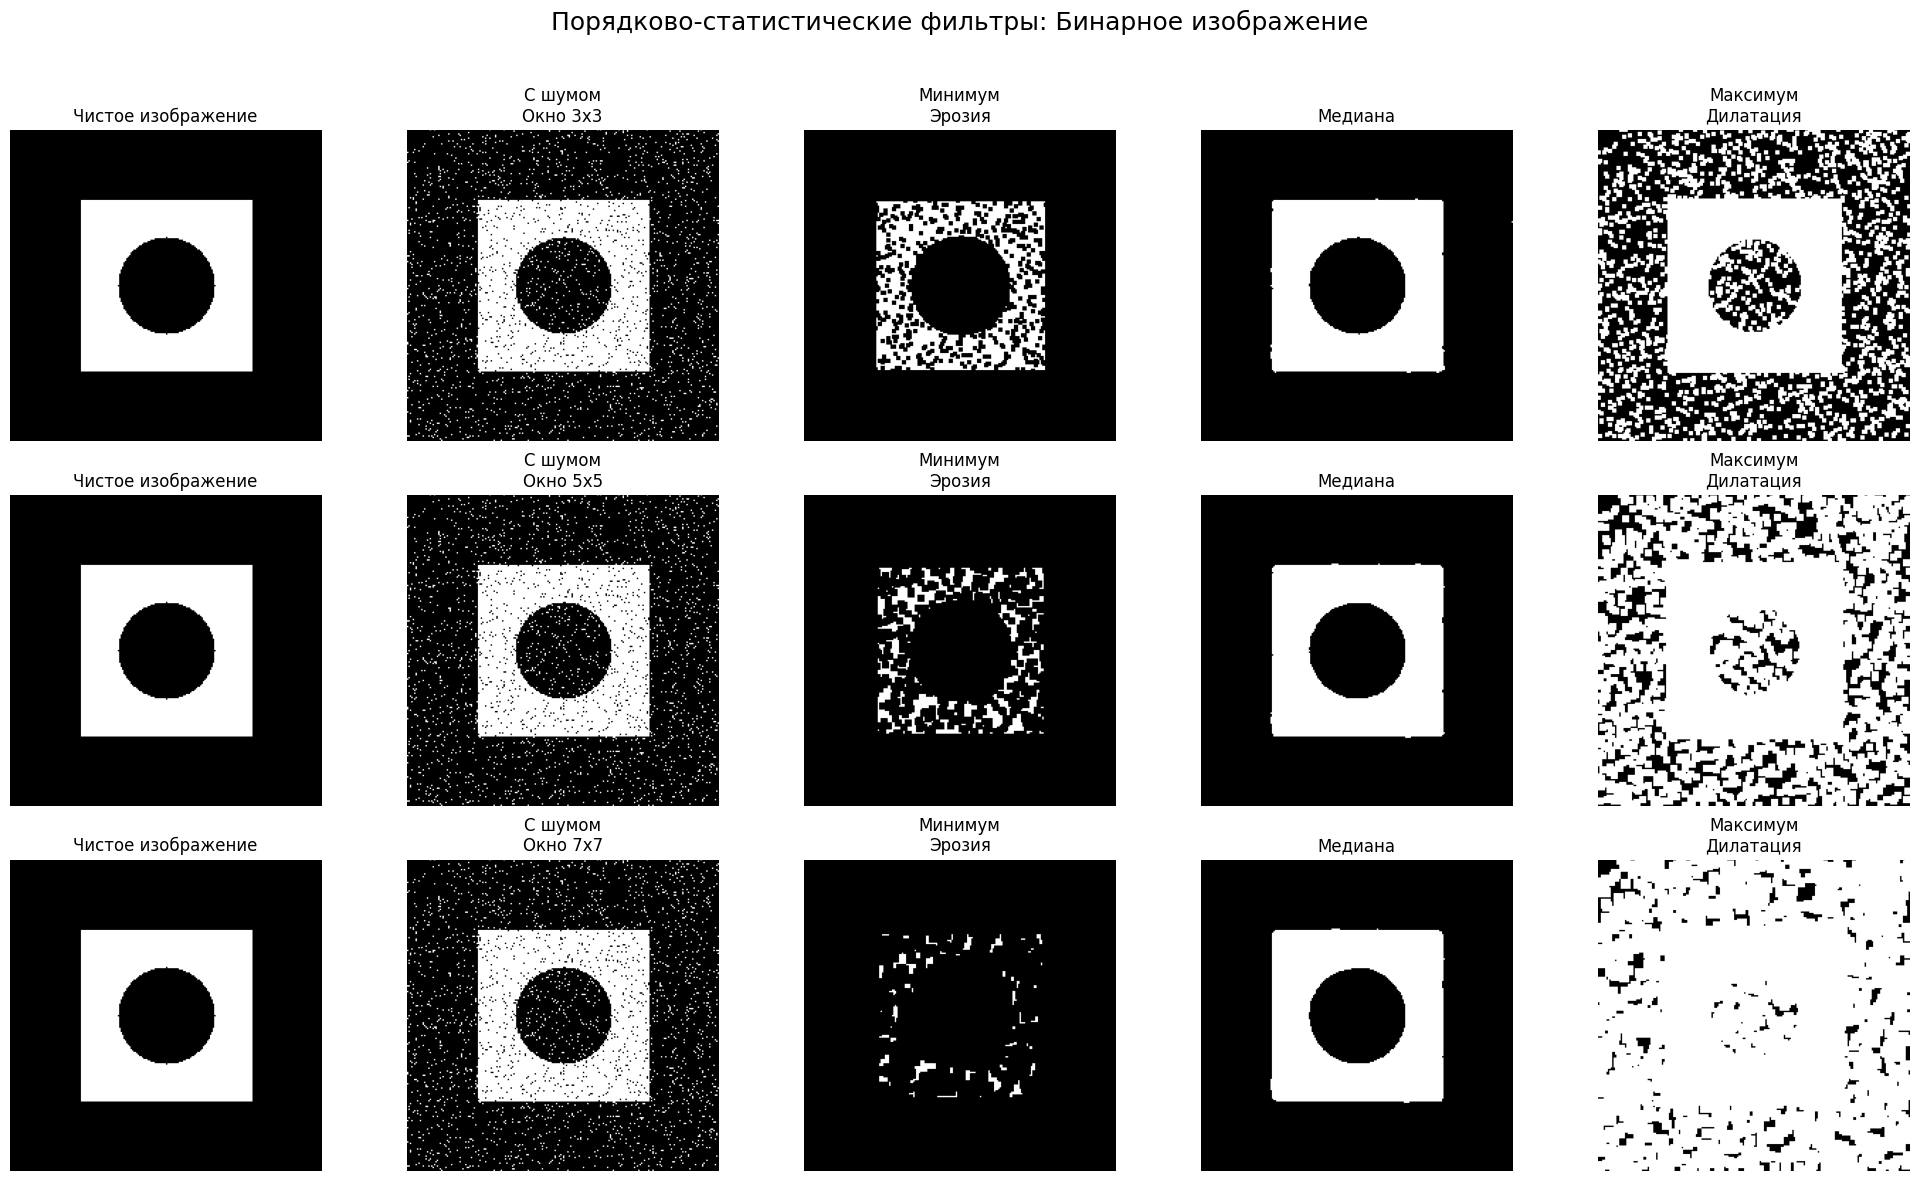

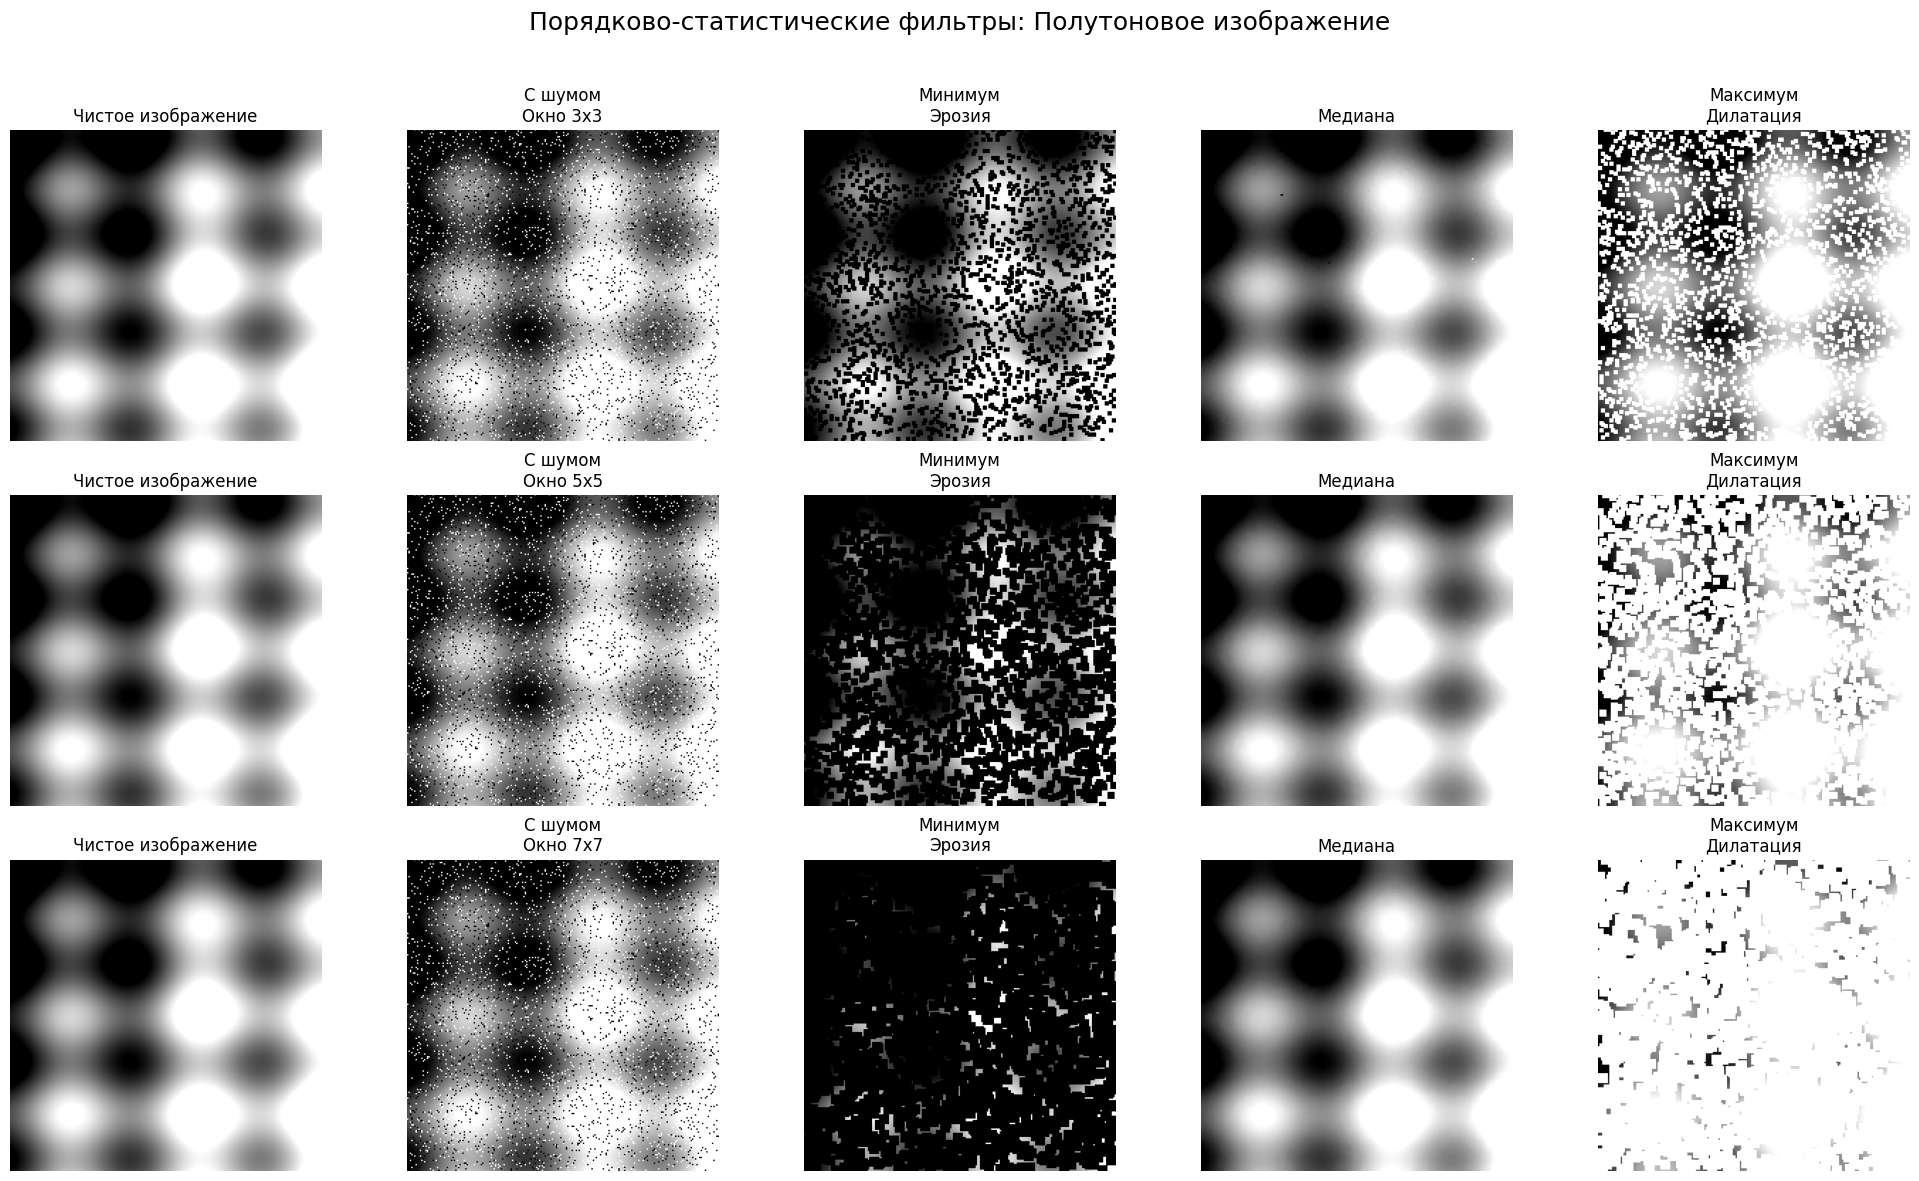

In [2]:
import importlib
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "cv2": "opencv-python",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
}

for module_name, package_name in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        importlib.invalidate_caches()

cv2 = importlib.import_module("cv2")
np = importlib.import_module("numpy")
plt = importlib.import_module("matplotlib.pyplot")

WINDOW_SIZES = (3, 5, 7)
NOISE_PROBABILITY = 0.10

def add_salt_and_pepper_noise(image, probability, seed):
    """Добавляет импульсный шум 'соль и перец' к изображению."""
    rng = np.random.default_rng(seed)
    noisy = image.copy()
    random_values = rng.random(image.shape)
    noisy[random_values < probability / 2] = 0
    noisy[random_values > 1 - probability / 2] = 255
    return noisy

def create_binary_image(shape=(220, 220)):
    """Создает бинарное изображение: квадрат с круглым отверстием."""
    image = np.zeros(shape, dtype=np.uint8)
    cv2.rectangle(image, (50, 50), (170, 170), 255, -1)
    cv2.circle(image, (110, 110), 34, 0, -1)
    return image

def create_grayscale_image(shape=(220, 220)):
    """Создает полутоновое изображение с плавным рельефом яркости."""
    x_values = np.linspace(-2.5, 2.5, shape[1])
    y_values = np.linspace(-2.5, 2.5, shape[0])
    x_grid, y_grid = np.meshgrid(x_values, y_values)

    sinusoidal = 80 * np.sin(3 * x_grid) + 60 * np.cos(4 * y_grid)
    gradient = 35 * (x_grid + y_grid)
    gaussian = 90 * np.exp(-((x_grid - 0.8) ** 2 + (y_grid + 0.6) ** 2) / 0.9)

    image = np.clip(128 + sinusoidal + gradient + gaussian, 0, 255).astype(np.uint8)
    return image

def apply_order_statistical_filters(noisy_image, window_sizes):
    """Применяет минимум, медиану и максимум для квадратных окон заданных размеров."""
    results = {}

    for size in window_sizes:
        kernel = np.ones((size, size), dtype=np.uint8)
        minimum_filtered = cv2.erode(noisy_image, kernel)
        median_filtered = cv2.medianBlur(noisy_image, size)
        maximum_filtered = cv2.dilate(noisy_image, kernel)

        results[size] = {
            "minimum": minimum_filtered,
            "median": median_filtered,
            "maximum": maximum_filtered,
        }

    return results

def count_binary_error(reference_image, processed_image):
    """Считает количество несовпадающих пикселей для бинарного изображения."""
    return int(np.count_nonzero(reference_image != processed_image))

def mean_absolute_error(reference_image, processed_image):
    """Считает среднюю абсолютную ошибку для полутонового изображения."""
    difference = np.abs(reference_image.astype(np.int16) - processed_image.astype(np.int16))
    return float(np.mean(difference))

def print_metrics(image_type, clean_image, noisy_image, filtered_results, is_binary):
    """Выводит численные характеристики до и после фильтрации."""
    print(image_type)
    if is_binary:
        noisy_error = count_binary_error(clean_image, noisy_image)
        print(f"Ошибочных пикселей в зашумленном изображении: {noisy_error}")
        for size, result_set in filtered_results.items():
            min_error = count_binary_error(clean_image, result_set["minimum"])
            med_error = count_binary_error(clean_image, result_set["median"])
            max_error = count_binary_error(clean_image, result_set["maximum"])
            print(
                f"Окно {size}x{size}: минимум = {min_error}, медиана = {med_error}, максимум = {max_error}"
            )
    else:
        noisy_mae = mean_absolute_error(clean_image, noisy_image)
        print(f"Средняя абсолютная ошибка в зашумленном изображении: {noisy_mae:.2f}")
        for size, result_set in filtered_results.items():
            min_mae = mean_absolute_error(clean_image, result_set["minimum"])
            med_mae = mean_absolute_error(clean_image, result_set["median"])
            max_mae = mean_absolute_error(clean_image, result_set["maximum"])
            print(
                f"Окно {size}x{size}: минимум = {min_mae:.2f}, медиана = {med_mae:.2f}, максимум = {max_mae:.2f}"
            )
    print()

def plot_filter_results(clean_image, noisy_image, filtered_results, title_prefix):
    """Строит сетку результатов фильтрации для одного типа изображения."""
    figure, axes = plt.subplots(len(WINDOW_SIZES), 5, figsize=(20, 12))
    figure.suptitle(f"Порядково-статистические фильтры: {title_prefix}", fontsize=18)

    for row_index, size in enumerate(WINDOW_SIZES):
        axes[row_index, 0].imshow(clean_image, cmap="gray", vmin=0, vmax=255)
        axes[row_index, 0].set_title("Чистое изображение")
        axes[row_index, 0].axis("off")

        axes[row_index, 1].imshow(noisy_image, cmap="gray", vmin=0, vmax=255)
        axes[row_index, 1].set_title(f"С шумом\nОкно {size}x{size}")
        axes[row_index, 1].axis("off")

        axes[row_index, 2].imshow(filtered_results[size]["minimum"], cmap="gray", vmin=0, vmax=255)
        axes[row_index, 2].set_title("Минимум\nЭрозия")
        axes[row_index, 2].axis("off")

        axes[row_index, 3].imshow(filtered_results[size]["median"], cmap="gray", vmin=0, vmax=255)
        axes[row_index, 3].set_title("Медиана")
        axes[row_index, 3].axis("off")

        axes[row_index, 4].imshow(filtered_results[size]["maximum"], cmap="gray", vmin=0, vmax=255)
        axes[row_index, 4].set_title("Максимум\nДилатация")
        axes[row_index, 4].axis("off")

    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()

binary_clean = create_binary_image()
binary_noisy = add_salt_and_pepper_noise(binary_clean, probability=NOISE_PROBABILITY, seed=7)

grayscale_clean = create_grayscale_image()
grayscale_noisy = add_salt_and_pepper_noise(grayscale_clean, probability=NOISE_PROBABILITY, seed=21)

binary_results = apply_order_statistical_filters(binary_noisy, WINDOW_SIZES)
grayscale_results = apply_order_statistical_filters(grayscale_noisy, WINDOW_SIZES)

print_metrics("Бинарное изображение", binary_clean, binary_noisy, binary_results, is_binary=True)
print_metrics("Полутоновое изображение", grayscale_clean, grayscale_noisy, grayscale_results, is_binary=False)

plot_filter_results(binary_clean, binary_noisy, binary_results, "Бинарное изображение")
plot_filter_results(grayscale_clean, grayscale_noisy, grayscale_results, "Полутоновое изображение")

## 4. Результат работы программы

После выполнения кода в ноутбуке формируются два графических блока `3x5`: один для бинарного изображения, второй для полутонового. Кроме того, программа выводит численные показатели качества обработки.

1. **Строки** соответствуют размерам квадратного окна: `3x3`, `5x5`, `7x7`.
2. **Столбцы** содержат чистое изображение, зашумленное изображение, результат фильтра минимума, медианного фильтра и фильтра максимума.
3. **Текстовый вывод** показывает численные ошибки: для бинарного изображения — количество несовпадающих пикселей, для полутонового — среднюю абсолютную ошибку.

**Анализ результата:**

1. **Фильтр минимума** удаляет светлый импульсный шум, но расширяет тёмные области и заметно разрушает светлые объекты при увеличении окна.
2. **Фильтр максимума** удаляет тёмный импульсный шум, но расширяет светлые области и усиливает светлые артефакты.
3. **Медианный фильтр** лучше всего подавляет шум типа «соль и перец» как на бинарном, так и на полутоновом изображении, особенно при окне `3x3`.
4. При увеличении окна до `5x5` и `7x7` шум подавляется сильнее, но возрастает потеря мелких деталей и искажение границ объектов.